# Dual-Cell Poisson GLM for Purkinje Cell Coupling

This notebook builds a basis-function Generalized Linear Model (GLM) for dual-cell in vivo voltage recordings from mouse cerebellar Purkinje cells. The main response modeled here is the 1 ms binned Simple Spike train of **Cell B** (`SS_B`). Predictors include Cell B's own Simple Spike history, Cell A Simple Spikes, Cell A Complex Spikes, and Cell B Complex Spikes.

The default path runs on synthetic data so the notebook is executable immediately. A real-data loader pools all matching Spike Detector GUI outputs with the same two-cell structure in `../data/20260611_A64_2PCs_MC/spike_detection/*_analyzed.npz`.

Interpretation convention: GLM filters are shown as relative firing intensity, `exp(filter)`. A value of `1.0` means no change from baseline, values above `1.0` indicate excitation, and values below `1.0` indicate inhibition.

## 1. Setup and Environment

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import gammaln
from sklearn.linear_model import PoissonRegressor

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
})

RNG_SEED = 7
USE_SYNTHETIC_DATA = False
REAL_DATA_FOLDER = Path('..') / 'data' / '20260611_A64_2PCs_MC' / 'spike_detection'
if not REAL_DATA_FOLDER.exists():
    REAL_DATA_FOLDER = Path('data') / '20260611_A64_2PCs_MC' / 'spike_detection'
REAL_SESSION_INDEX = 0  # used only when LOAD_ALL_REAL_SESSIONS is False
LOAD_ALL_REAL_SESSIONS = True

DT_MS = 1.0
DT_S = DT_MS / 1000.0
print(f'Using 1 ms bins; synthetic mode = {USE_SYNTHETIC_DATA}')

Using 1 ms bins; synthetic mode = False


## 2. Raised Cosine Basis Set

In [2]:
def make_raised_cosine_basis(start_ms, end_ms, n_basis, dt_ms=1.0, log_offset_ms=5.0):
    """Create log-time raised cosine basis functions for causal spike-history filters.

    Parameters
    ----------
    start_ms, end_ms : float
        Inclusive lag range represented by the basis. Lag 0 is allowed for cross-cell
        predictors, but self-history should start at lag 1 to avoid current-bin leakage.
    n_basis : int
        Number of basis functions.
    dt_ms : float
        Time-bin width in milliseconds.
    log_offset_ms : float
        Positive offset before the log transform. Smaller values place more basis centers
        at very short latencies, which helps capture refractory periods and synaptic delays.

    Returns
    -------
    lags_ms : ndarray, shape (n_lags,)
        Lags represented by rows of the basis matrix.
    basis : ndarray, shape (n_lags, n_basis)
        Raised cosine basis functions evaluated at each lag.
    centers_ms : ndarray, shape (n_basis,)
        Basis centers converted back to milliseconds for plotting/inspection.
    """
    if start_ms < 0 or end_ms < start_ms:
        raise ValueError('Expected 0 <= start_ms <= end_ms')
    if n_basis < 1:
        raise ValueError('n_basis must be at least 1')
    if log_offset_ms <= 0:
        raise ValueError('log_offset_ms must be positive')

    lags_ms = np.arange(start_ms, end_ms + 0.5 * dt_ms, dt_ms, dtype=float)
    transformed_lags = np.log(lags_ms + log_offset_ms)
    centers = np.linspace(transformed_lags[0], transformed_lags[-1], n_basis)

    if n_basis == 1:
        width = transformed_lags[-1] - transformed_lags[0] + 1e-12
    else:
        width = centers[1] - centers[0]

    basis = np.zeros((lags_ms.size, n_basis), dtype=float)
    for i, c in enumerate(centers):
        phase = (transformed_lags - c) * np.pi / width
        mask = np.abs(phase) <= np.pi
        basis[mask, i] = 0.5 * (np.cos(phase[mask]) + 1.0)

    # Normalize each column to peak at 1. This keeps reconstructed filters in natural
    # log-intensity units while still letting the basis share temporal support.
    col_max = basis.max(axis=0, keepdims=True)
    basis = np.divide(basis, col_max, out=np.zeros_like(basis), where=col_max > 0)
    centers_ms = np.exp(centers) - log_offset_ms
    return lags_ms, basis, centers_ms

lags_50, basis_50, centers_50 = make_raised_cosine_basis(0, 50, n_basis=8)
lags_100, basis_100, centers_100 = make_raised_cosine_basis(0, 100, n_basis=10)
print('50 ms basis:', basis_50.shape, '100 ms basis:', basis_100.shape)

50 ms basis: (51, 8) 100 ms basis: (101, 10)


## 3. Synthetic Data Generator

In [3]:
def _sample_refractory_poisson(n_bins, baseline_hz, rng, dt_s=0.001, abs_ref_ms=3, recovery_ms=15):
    """Sample a Bernoulli spike train with a simple absolute/relative refractory rule."""
    spikes = np.zeros(n_bins, dtype=np.int8)
    last_spike = -10_000
    for t in range(n_bins):
        lag = t - last_spike
        if lag <= abs_ref_ms:
            p = 0.0
        elif lag < recovery_ms:
            # Recovery ramps from near-silent after the absolute refractory period to baseline.
            recovery = (lag - abs_ref_ms) / max(1, recovery_ms - abs_ref_ms)
            p = baseline_hz * dt_s * recovery
        else:
            p = baseline_hz * dt_s
        if rng.random() < p:
            spikes[t] = 1
            last_spike = t
    return spikes


def simulate_dual_cell_recording(duration_s=300.0, dt_ms=1.0, seed=7):
    """Simulate dual-cell SS/CS trains with refractory effects, coupling, and CS common drive.

    The synthetic data intentionally contains a directional effect: Cell A CS events suppress
    Cell B SS firing after a 2 ms delay for about 20 ms. It also contains simultaneous CS_A/CS_B
    events, mimicking shared climbing fiber input that should be controlled by including CS_B.
    """
    rng = np.random.default_rng(seed)
    dt_s = dt_ms / 1000.0
    n_bins = int(round(duration_s / dt_s))
    time_ms = np.arange(n_bins, dtype=float) * dt_ms

    ss_a = _sample_refractory_poisson(n_bins, baseline_hz=115.0, rng=rng, dt_s=dt_s)

    # Sparse complex spikes with a common-drive component shared by both cells.
    cs_a_private = (rng.random(n_bins) < (0.65 * dt_s)).astype(np.int8)
    cs_b_private = (rng.random(n_bins) < (0.65 * dt_s)).astype(np.int8)
    common_drive = (rng.random(n_bins) < (0.35 * dt_s)).astype(np.int8)
    cs_a = np.clip(cs_a_private + common_drive, 0, 1).astype(np.int8)
    cs_b = np.clip(cs_b_private + common_drive, 0, 1).astype(np.int8)

    # Build the true CS_A -> SS_B log-intensity modulation used by the simulator.
    true_cs_a_filter = np.zeros(101, dtype=float)
    true_cs_a_filter[2:22] = -2.0  # 2 ms delay, 20 ms inhibition.
    cs_a_drive = np.convolve(cs_a, true_cs_a_filter, mode='full')[:n_bins]

    ss_b = np.zeros(n_bins, dtype=np.int8)
    last_ss_b = -10_000
    baseline_log_p = np.log(150.0 * dt_s)
    for t in range(n_bins):
        lag = t - last_ss_b
        if lag <= 3:
            self_history = -12.0  # absolute refractory period.
        elif lag < 15:
            self_history = -3.0 * (1.0 - (lag - 3) / 12.0)  # recovery by 15 ms.
        else:
            self_history = 0.0
        p = np.exp(baseline_log_p + self_history + cs_a_drive[t])
        p = min(float(p), 0.8)
        if rng.random() < p:
            ss_b[t] = 1
            last_ss_b = t

    data = {
        'time_ms': time_ms,
        'dt_ms': dt_ms,
        'SS_A': ss_a,
        'CS_A': cs_a,
        'SS_B': ss_b,
        'CS_B': cs_b,
        'source': 'synthetic',
        'true_cs_a_to_ss_b_log_filter': true_cs_a_filter,
    }
    return data


def summarize_spike_rates(data):
    duration_s = data['time_ms'].size * data['dt_ms'] / 1000.0
    for name in ['SS_A', 'CS_A', 'SS_B', 'CS_B']:
        rate = data[name].sum() / duration_s
        print(f'{name}: {int(data[name].sum()):5d} spikes, {rate:6.2f} Hz')

if USE_SYNTHETIC_DATA:
    synthetic_data = simulate_dual_cell_recording(duration_s=300.0, dt_ms=DT_MS, seed=RNG_SEED)
    summarize_spike_rates(synthetic_data)
else:
    synthetic_data = None
    print('Synthetic generator defined; skipped because USE_SYNTHETIC_DATA=False')

Synthetic generator defined; skipped because USE_SYNTHETIC_DATA=False


## 4. Optional Real-Data Loader

In [4]:
def bin_spike_times_ms(spike_times_ms, duration_ms, dt_ms=1.0):
    """Convert Spike Detector event times in milliseconds to 1 ms binned spike counts."""
    n_bins = int(np.ceil(duration_ms / dt_ms))
    counts = np.zeros(n_bins, dtype=np.int16)
    spike_times_ms = np.asarray(spike_times_ms, dtype=float)
    spike_times_ms = spike_times_ms[np.isfinite(spike_times_ms)]
    bin_idx = np.floor(spike_times_ms / dt_ms).astype(int)
    bin_idx = bin_idx[(bin_idx >= 0) & (bin_idx < n_bins)]
    np.add.at(counts, bin_idx, 1)
    return counts


def _natural_session_key(path):
    """Sort pair_MC_1, pair_MC_2, ..., pair_MC_11 in recording order."""
    import re
    parts = re.split(r'(\d+)', Path(path).stem)
    return [int(p) if p.isdigit() else p for p in parts]


def load_dual_cell_npz(npz_path, dt_ms=1.0):
    """Load one Spike Detector GUI output and map cell 0 to Cell A, cell 1 to Cell B."""
    with np.load(npz_path, allow_pickle=True) as d:
        time_ms_original = np.asarray(d['time_ms'], dtype=float).reshape(-1)
        duration_ms = float(time_ms_original[-1] - time_ms_original[0] + dt_ms)
        cell_names = [str(x) for x in np.asarray(d['cell_names']).tolist()]
        if len(cell_names) < 2:
            raise ValueError('This GLM notebook expects at least two detected cells.')

        spike_times_ss = np.asarray(d['spike_times_ss'], dtype=object)
        spike_times_cs = np.asarray(d['spike_times_cs'], dtype=object)

        data = {
            'time_ms': np.arange(int(np.ceil(duration_ms / dt_ms)), dtype=float) * dt_ms,
            'dt_ms': dt_ms,
            'SS_A': bin_spike_times_ms(spike_times_ss[0], duration_ms, dt_ms),
            'CS_A': bin_spike_times_ms(spike_times_cs[0], duration_ms, dt_ms),
            'SS_B': bin_spike_times_ms(spike_times_ss[1], duration_ms, dt_ms),
            'CS_B': bin_spike_times_ms(spike_times_cs[1], duration_ms, dt_ms),
            'cell_names': cell_names[:2],
            'session_name': Path(npz_path).stem,
            'source': str(npz_path),
        }
    return data


def load_all_dual_cell_npz_sessions(folder, dt_ms=1.0, strict_cell_names=True):
    """Load all two-cell sessions in a folder and verify a stable cell structure.

    The returned object keeps individual sessions, because the GLM design matrix must be
    constructed per session. This prevents artificial history terms that would otherwise connect
    the final spike of one recording to the first bins of the next recording.
    """
    files = sorted(Path(folder).glob('*_analyzed.npz'), key=_natural_session_key)
    if not files:
        raise FileNotFoundError(f'No *_analyzed.npz files found in {folder}')

    sessions = []
    reference_names = None
    excluded = []
    for p in files:
        try:
            session = load_dual_cell_npz(p, dt_ms=dt_ms)
            if reference_names is None:
                reference_names = session['cell_names']
            elif strict_cell_names and session['cell_names'] != reference_names:
                excluded.append({'path': str(p), 'reason': f'cell names/order differ: {session["cell_names"]}'})
                continue
            sessions.append(session)
        except Exception as exc:
            excluded.append({'path': str(p), 'reason': str(exc)})

    if not sessions:
        raise ValueError('No valid two-cell sessions were loaded.')

    # Concatenated vectors are used only for simple rate summaries and sanity checks.
    pooled = {
        'sessions': sessions,
        'excluded_sessions': excluded,
        'cell_names': reference_names,
        'dt_ms': dt_ms,
        'time_ms': np.arange(sum(s['time_ms'].size for s in sessions), dtype=float) * dt_ms,
        'SS_A': np.concatenate([s['SS_A'] for s in sessions]),
        'CS_A': np.concatenate([s['CS_A'] for s in sessions]),
        'SS_B': np.concatenate([s['SS_B'] for s in sessions]),
        'CS_B': np.concatenate([s['CS_B'] for s in sessions]),
        'source': f'{len(sessions)} sessions from {folder}',
    }
    return pooled


npz_files = sorted(REAL_DATA_FOLDER.glob('*_analyzed.npz'), key=_natural_session_key)
print(f'Found {len(npz_files)} real-data sessions in {REAL_DATA_FOLDER}')
if npz_files:
    print('Example session:', npz_files[0].name)

if USE_SYNTHETIC_DATA:
    data = synthetic_data
else:
    if LOAD_ALL_REAL_SESSIONS:
        data = load_all_dual_cell_npz_sessions(REAL_DATA_FOLDER, dt_ms=DT_MS, strict_cell_names=True)
        print(f'Loaded sessions: {len(data["sessions"])}')
        print(f'Excluded sessions: {len(data["excluded_sessions"])}')
        if data['excluded_sessions']:
            for ex in data['excluded_sessions']:
                print(f'- excluded {ex["path"]}: {ex["reason"]}')
        summarize_spike_rates(data)
    else:
        data = load_dual_cell_npz(npz_files[REAL_SESSION_INDEX], dt_ms=DT_MS)
        summarize_spike_rates(data)

print('Active dataset:', data['source'])

Found 10 real-data sessions in ../data/20260611_A64_2PCs_MC/spike_detection
Example session: pair_MC_1_analyzed.npz
Loaded sessions: 10
Excluded sessions: 0
SS_A:  2383 spikes,  23.83 Hz
CS_A:    91 spikes,   0.91 Hz
SS_B:  2515 spikes,  25.15 Hz
CS_B:    96 spikes,   0.96 Hz
Active dataset: 10 sessions from ../data/20260611_A64_2PCs_MC/spike_detection


## 5. Design Matrix Engineering

In [5]:
def convolve_spike_train_with_basis(spike_train, basis, start_lag_ms, dt_ms=1.0):
    """Convolve a binned spike train with causal basis functions.

    The returned feature at row t is the weighted sum of spikes at t - lag. For self-history,
    pass start_lag_ms=1 so the response spike in the current bin cannot predict itself.
    For cross-cell predictors, lag 0 can be useful because true synchrony/common input may be
    exactly simultaneous at the chosen bin width.
    """
    spike_train = np.asarray(spike_train, dtype=float).reshape(-1)
    start_lag_bins = int(round(start_lag_ms / dt_ms))
    n_lags, n_basis = basis.shape
    kernel_len = start_lag_bins + n_lags
    features = np.zeros((spike_train.size, n_basis), dtype=float)

    for j in range(n_basis):
        kernel = np.zeros(kernel_len, dtype=float)
        kernel[start_lag_bins:start_lag_bins + n_lags] = basis[:, j]
        # np.convolve uses kernel[k] with spike[t-k], giving a causal history feature.
        features[:, j] = np.convolve(spike_train, kernel, mode='full')[:spike_train.size]
    return features


def _build_single_session_ss_b_design_matrix(session, dt_ms=1.0):
    """Build one session matrix; called before pooling to avoid cross-session leakage."""
    ss_basis_lags, ss_basis, _ = make_raised_cosine_basis(0, 49, n_basis=8, dt_ms=dt_ms)
    cs_basis_lags, cs_basis, _ = make_raised_cosine_basis(0, 100, n_basis=10, dt_ms=dt_ms)

    blocks = []
    slices = {}
    names = []

    def add_block(name, values):
        start = sum(block.shape[1] for block in blocks)
        blocks.append(values)
        slices[name] = slice(start, start + values.shape[1])
        names.extend([f'{name}_{i}' for i in range(values.shape[1])])

    n_bins = session['SS_B'].size
    add_block('intercept', np.ones((n_bins, 1), dtype=float))

    # Self-history starts at lag 1 ms: this captures refractoriness without leaking y[t] into X[t].
    add_block('h_SS_B', convolve_spike_train_with_basis(session['SS_B'], ss_basis, start_lag_ms=1, dt_ms=dt_ms))

    # Cross-cell SS coupling can include lag 0, because same-bin synchrony is a possible observation.
    add_block('J_SS_A_to_SS_B', convolve_spike_train_with_basis(session['SS_A'], ss_basis, start_lag_ms=0, dt_ms=dt_ms))

    # CS_A tests the directional hypothesis: Cell A complex spikes modulate Cell B simple spikes.
    add_block('J_CS_A_to_SS_B', convolve_spike_train_with_basis(session['CS_A'], cs_basis, start_lag_ms=0, dt_ms=dt_ms))

    # CS_B is a control for Cell B's own CS pause and common climbing-fiber drive.
    add_block('J_CS_B_to_SS_B', convolve_spike_train_with_basis(session['CS_B'], cs_basis, start_lag_ms=0, dt_ms=dt_ms))

    X_full = np.column_stack(blocks)
    y_full = np.asarray(session['SS_B'], dtype=float)

    max_lag_bins = int(round(101 / dt_ms))
    X = X_full[max_lag_bins:]
    y = y_full[max_lag_bins:]

    meta = {
        'slices': slices,
        'names': names,
        'ss_basis': ss_basis,
        'ss_lags_ms': ss_basis_lags,
        'cs_basis': cs_basis,
        'cs_lags_ms': cs_basis_lags,
        'trim_bins': max_lag_bins,
    }
    return X, y, meta


def build_ss_b_design_matrix(data, dt_ms=1.0):
    """Build X for predicting Cell B Simple Spike counts in 1 ms bins.

    If `data` contains multiple sessions, each session is transformed independently and then
    stacked. That preserves causal history within each recording while increasing statistical
    power across repeated trials/sessions.
    """
    if 'sessions' in data:
        X_parts = []
        y_parts = []
        session_rows = []
        meta = None
        row_start = 0
        for session in data['sessions']:
            X_s, y_s, meta = _build_single_session_ss_b_design_matrix(session, dt_ms=dt_ms)
            X_parts.append(X_s)
            y_parts.append(y_s)
            row_end = row_start + X_s.shape[0]
            session_rows.append({
                'session_name': session.get('session_name', 'session'),
                'row_start': row_start,
                'row_end': row_end,
                'n_rows': X_s.shape[0],
                'n_SS_B_response_spikes': int(y_s.sum()),
            })
            row_start = row_end
        meta = dict(meta)
        meta['session_rows'] = session_rows
        return np.vstack(X_parts), np.concatenate(y_parts), meta

    return _build_single_session_ss_b_design_matrix(data, dt_ms=dt_ms)


X, y, design_meta = build_ss_b_design_matrix(data, dt_ms=DT_MS)
print('X shape:', X.shape, 'y shape:', y.shape)
assert X.shape[0] == y.shape[0]
assert design_meta['slices']['h_SS_B'].start == 1
print('Trimmed first bins per session to remove filter warm-up:', design_meta['trim_bins'])
if 'session_rows' in design_meta:
    print('Pooled design matrices from sessions:')
    for row in design_meta['session_rows']:
        print(f"- {row['session_name']}: {row['n_rows']} rows, {row['n_SS_B_response_spikes']} SS_B response spikes")

X shape: (99000, 37) y shape: (99000,)
Trimmed first bins per session to remove filter warm-up: 101
Pooled design matrices from sessions:
- pair_MC_1_analyzed: 9900 rows, 297 SS_B response spikes
- pair_MC_2_analyzed: 9900 rows, 270 SS_B response spikes
- pair_MC_3_analyzed: 9900 rows, 248 SS_B response spikes
- pair_MC_4_analyzed: 9900 rows, 232 SS_B response spikes
- pair_MC_5_analyzed: 9900 rows, 230 SS_B response spikes
- pair_MC_6_analyzed: 9900 rows, 263 SS_B response spikes
- pair_MC_7_analyzed: 9900 rows, 233 SS_B response spikes
- pair_MC_8_analyzed: 9900 rows, 252 SS_B response spikes
- pair_MC_9_analyzed: 9900 rows, 256 SS_B response spikes
- pair_MC_11_analyzed: 9900 rows, 234 SS_B response spikes


## 6. Model Fitting and Regularization

In [6]:
def poisson_log_likelihood(y, mu):
    """Poisson log-likelihood, including the log-factorial term for comparability."""
    y = np.asarray(y, dtype=float)
    mu = np.clip(np.asarray(mu, dtype=float), 1e-12, None)
    return float(np.sum(y * np.log(mu) - mu - gammaln(y + 1.0)))


def fit_poisson_glm_alpha_grid(X, y, alphas=(1e-5, 1e-4, 0.001, 0.01, 0.1), train_fraction=0.8):
    """Fit ridge-regularized Poisson GLMs and score them on a contiguous test segment."""
    split_idx = int(np.floor(train_fraction * X.shape[0]))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    baseline_mu = np.repeat(max(y_train.mean(), 1e-12), y_test.size)
    ll_baseline = poisson_log_likelihood(y_test, baseline_mu)

    rows = []
    models = {}
    for alpha in alphas:
        model = PoissonRegressor(alpha=float(alpha), fit_intercept=False, max_iter=1000, tol=1e-8)
        model.fit(X_train, y_train)
        mu_test = model.predict(X_test)
        ll_test = poisson_log_likelihood(y_test, mu_test)
        pseudo_r2 = 1.0 - (ll_test / ll_baseline) if ll_baseline != 0 else np.nan
        rows.append({
            'alpha': float(alpha),
            'test_log_likelihood': ll_test,
            'baseline_log_likelihood': ll_baseline,
            'pseudo_R2': pseudo_r2,
            'mean_rate_test_Hz': mu_test.mean() / DT_S,
        })
        models[float(alpha)] = model

    best_row = max(rows, key=lambda r: r['test_log_likelihood'])
    return best_row, rows, models, split_idx

alpha_grid = (1e-5, 1e-4, 0.001, 0.01, 0.1)
best_row, score_rows, models, split_idx = fit_poisson_glm_alpha_grid(X, y, alpha_grid)
best_model = models[best_row['alpha']]

print('Train bins:', split_idx, 'Test bins:', X.shape[0] - split_idx)
print('alpha\ttest logLik\tpseudo-R2\tmean predicted test rate (Hz)')
for row in score_rows:
    marker = '*' if row['alpha'] == best_row['alpha'] else ' '
    print(f"{marker}{row['alpha']:>6g}\t{row['test_log_likelihood']:>12.2f}\t{row['pseudo_R2']:>8.4f}\t{row['mean_rate_test_Hz']:>8.2f}")

Train bins: 79200 Test bins: 19800
alpha	test logLik	pseudo-R2	mean predicted test rate (Hz)
* 1e-05	    -2280.41	  0.0097	   25.79
 0.0001	    -2280.67	  0.0096	   26.10
  0.001	    -2291.72	  0.0048	   29.31
   0.01	    -2492.60	 -0.0824	   51.94
    0.1	    -4189.41	 -0.8193	  166.45


## 7. Filter Reconstruction

In [7]:
def reconstruct_filter(model, meta, block_name):
    """Project fitted basis weights back into a full time-domain log-intensity filter."""
    sl = meta['slices'][block_name]
    weights = model.coef_[sl]
    if block_name.startswith('J_CS'):
        basis = meta['cs_basis']
        lags_ms = meta['cs_lags_ms']
    else:
        basis = meta['ss_basis']
        lags_ms = meta['ss_lags_ms']
        if block_name == 'h_SS_B':
            # The self-history convolution starts at lag 1 ms to avoid y[t] leakage,
            # so report the effective latency as 1-50 ms rather than basis rows 0-49 ms.
            lags_ms = lags_ms + 1.0
    log_filter = basis @ weights
    return lags_ms, log_filter, np.exp(log_filter), weights

filters = {}
for block in ['h_SS_B', 'J_SS_A_to_SS_B', 'J_CS_A_to_SS_B', 'J_CS_B_to_SS_B']:
    filters[block] = reconstruct_filter(best_model, design_meta, block)

intercept_log_count = best_model.coef_[design_meta['slices']['intercept']][0]
print(f'Best alpha: {best_row["alpha"]}; intercept-only-equivalent rate: {np.exp(intercept_log_count) / DT_S:.2f} Hz')

Best alpha: 1e-05; intercept-only-equivalent rate: 29.84 Hz


## 8. Visualization and Interpretation

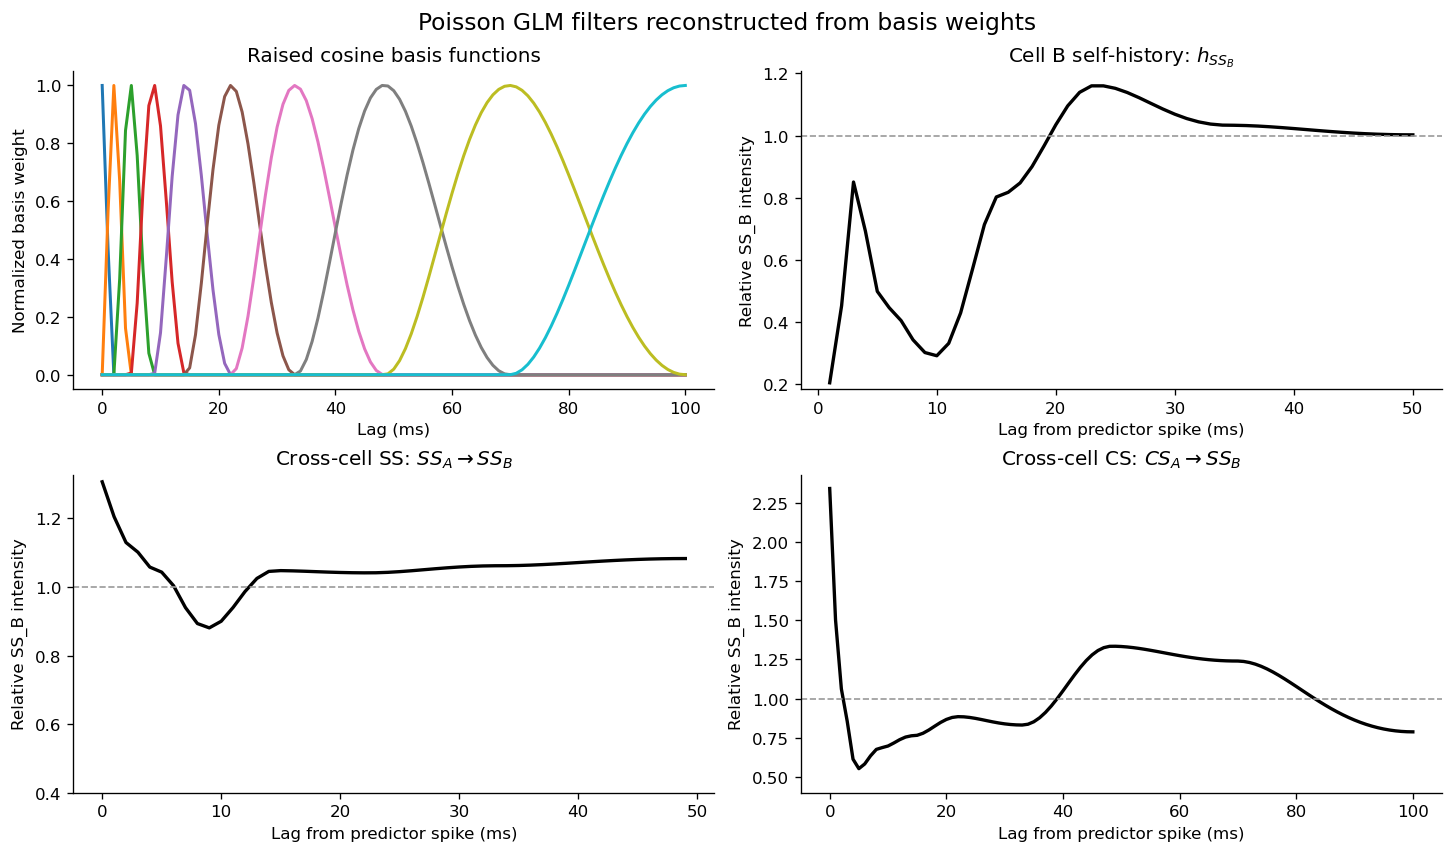

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

ax = axes[0, 0]
for j in range(basis_100.shape[1]):
    ax.plot(lags_100, basis_100[:, j], lw=1.8)
ax.set_title('Raised cosine basis functions')
ax.set_xlabel('Lag (ms)')
ax.set_ylabel('Normalized basis weight')

plot_specs = [
    ('h_SS_B', 'Cell B self-history: $h_{SS_B}$', axes[0, 1]),
    ('J_SS_A_to_SS_B', 'Cross-cell SS: $SS_A \\rightarrow SS_B$', axes[1, 0]),
    ('J_CS_A_to_SS_B', 'Cross-cell CS: $CS_A \\rightarrow SS_B$', axes[1, 1]),
]

for block, title, ax in plot_specs:
    lags_ms, log_filter, rel_intensity, _ = filters[block]
    ax.plot(lags_ms, rel_intensity, color='black', lw=2)
    ax.axhline(1.0, color='0.6', ls='--', lw=1)
    ax.set_title(title)
    ax.set_xlabel('Lag from predictor spike (ms)')
    ax.set_ylabel('Relative SS_B intensity')
    ax.set_ylim(bottom=max(0.0, min(0.4, rel_intensity.min() * 0.9)))

fig.suptitle('Poisson GLM filters reconstructed from basis weights', fontsize=14)
plt.show()

## 9. Basic Sanity Checks

In [9]:
# These checks make the notebook safer to modify: they test shape consistency, finite scores,
# and the most important causal convention: SS_B self-history never includes the current bin.
assert X.shape[0] == y.shape[0]
assert np.all(np.isfinite(X)) and np.all(np.isfinite(y))
assert all(np.isfinite(row['test_log_likelihood']) for row in score_rows)
assert all(np.isfinite(row['pseudo_R2']) for row in score_rows)

self_features_full = convolve_spike_train_with_basis(data['SS_B'], design_meta['ss_basis'], start_lag_ms=1, dt_ms=DT_MS)
current_spike_bins = np.flatnonzero(data['SS_B'] > 0)
if current_spike_bins.size:
    first_spike = current_spike_bins[0]
    # With start_lag_ms=1, a spike in bin t cannot contribute to X[t]; only earlier spikes can.
    direct_current_contribution = convolve_spike_train_with_basis(
        np.eye(1, data['SS_B'].size, first_spike).ravel(),
        design_meta['ss_basis'],
        start_lag_ms=1,
        dt_ms=DT_MS,
    )[first_spike]
    assert np.allclose(direct_current_contribution, 0.0)

if data['source'] == 'synthetic':
    cs_lags, _, cs_rel, _ = filters['J_CS_A_to_SS_B']
    inhibitory_window = (cs_lags >= 2) & (cs_lags < 25)
    print('Synthetic CS_A -> SS_B mean relative intensity, 2-25 ms:', cs_rel[inhibitory_window].mean())

if 'session_rows' in design_meta:
    print('Confirmed pooled design was built session-by-session; history filters do not cross recording boundaries.')
print('All notebook sanity checks passed.')

Confirmed pooled design was built session-by-session; history filters do not cross recording boundaries.
All notebook sanity checks passed.


## 10. Full 4 x 4 Pairwise GLM Report

The main analysis above focuses on `SS_B`. This section expands the same logic to all directed relationships among four event trains: `SS_A`, `CS_A`, `SS_B`, and `CS_B`.

For each response train, the model includes histories of all four trains at once. That means a displayed source filter is interpreted **conditional on the other spike histories in the model**, not as a simple raw cross-correlation. Self-history terms start at 1 ms to avoid current-bin leakage; cross-history terms may include 0 ms to capture synchrony/common-drive structure.

In [10]:
EVENT_KEYS = ['SS_A', 'CS_A', 'SS_B', 'CS_B']
EVENT_LABELS = {
    'SS_A': 'Cell A SS',
    'CS_A': 'Cell A CS',
    'SS_B': 'Cell B SS',
    'CS_B': 'Cell B CS',
}


def _basis_for_event_key(event_key, dt_ms=1.0):
    """Use shorter SS windows and longer CS windows for readable pairwise filters."""
    if event_key.startswith('SS'):
        return make_raised_cosine_basis(0, 49, n_basis=8, dt_ms=dt_ms)
    return make_raised_cosine_basis(0, 100, n_basis=10, dt_ms=dt_ms)


def _build_single_session_response_design_matrix(session, response_key, event_keys=EVENT_KEYS, dt_ms=1.0):
    """Build one response model with all event histories as simultaneous predictors."""
    blocks = []
    slices = {}
    basis_by_source = {}
    lags_by_source = {}

    def add_block(name, values):
        start = sum(block.shape[1] for block in blocks)
        blocks.append(values)
        slices[name] = slice(start, start + values.shape[1])

    n_bins = session[response_key].size
    add_block('intercept', np.ones((n_bins, 1), dtype=float))

    for source_key in event_keys:
        lags_ms, basis, _ = _basis_for_event_key(source_key, dt_ms=dt_ms)
        start_lag_ms = 1.0 if source_key == response_key else 0.0
        block_name = f'{source_key}_to_{response_key}'
        add_block(block_name, convolve_spike_train_with_basis(session[source_key], basis, start_lag_ms=start_lag_ms, dt_ms=dt_ms))
        basis_by_source[source_key] = basis
        lags_by_source[source_key] = lags_ms + start_lag_ms

    X_full = np.column_stack(blocks)
    y_full = np.asarray(session[response_key], dtype=float)
    max_lag_bins = int(round(101 / dt_ms))
    return X_full[max_lag_bins:], y_full[max_lag_bins:], {
        'slices': slices,
        'basis_by_source': basis_by_source,
        'lags_by_source': lags_by_source,
        'trim_bins': max_lag_bins,
        'response_key': response_key,
        'event_keys': list(event_keys),
    }


def build_response_design_matrix(data, response_key, event_keys=EVENT_KEYS, dt_ms=1.0):
    """Build a pooled all-history model for one response train."""
    sessions = data['sessions'] if 'sessions' in data else [data]
    X_parts = []
    y_parts = []
    session_rows = []
    meta = None
    row_start = 0
    for session in sessions:
        X_s, y_s, meta = _build_single_session_response_design_matrix(session, response_key, event_keys=event_keys, dt_ms=dt_ms)
        X_parts.append(X_s)
        y_parts.append(y_s)
        row_end = row_start + X_s.shape[0]
        session_rows.append({
            'session_name': session.get('session_name', 'session'),
            'row_start': row_start,
            'row_end': row_end,
            'n_rows': X_s.shape[0],
            'n_response_spikes': int(y_s.sum()),
        })
        row_start = row_end
    meta = dict(meta)
    meta['session_rows'] = session_rows
    return np.vstack(X_parts), np.concatenate(y_parts), meta


def reconstruct_source_filter(model, meta, source_key):
    """Recover the fitted source -> response filter as relative intensity."""
    response_key = meta['response_key']
    block_name = f'{source_key}_to_{response_key}'
    weights = model.coef_[meta['slices'][block_name]]
    basis = meta['basis_by_source'][source_key]
    lags_ms = meta['lags_by_source'][source_key]
    log_filter = basis @ weights
    return lags_ms, log_filter, np.exp(log_filter)


def fit_all_pairwise_glms(data, event_keys=EVENT_KEYS, alpha_grid=(1e-5, 1e-4, 1e-3, 1e-2, 1e-1), dt_ms=1.0):
    """Fit one all-history Poisson GLM per response and summarize all source filters."""
    models_by_response = {}
    filters_by_pair = {}
    summary_rows = []

    for response_key in event_keys:
        X_r, y_r, meta_r = build_response_design_matrix(data, response_key, event_keys=event_keys, dt_ms=dt_ms)
        best_r, score_rows_r, models_r, split_r = fit_poisson_glm_alpha_grid(X_r, y_r, alphas=alpha_grid, train_fraction=0.8)
        model_r = models_r[best_r['alpha']]
        models_by_response[response_key] = {
            'model': model_r,
            'meta': meta_r,
            'scores': score_rows_r,
            'best': best_r,
            'split_idx': split_r,
            'n_response_spikes': int(y_r.sum()),
            'n_test_spikes': int(y_r[split_r:].sum()),
        }

        for source_key in event_keys:
            lags_ms, log_filter, rel_intensity = reconstruct_source_filter(model_r, meta_r, source_key)
            filters_by_pair[(source_key, response_key)] = {
                'lags_ms': lags_ms,
                'log_filter': log_filter,
                'relative_intensity': rel_intensity,
            }
            early_window = (lags_ms >= (1.0 if source_key == response_key else 0.0)) & (lags_ms <= 10.0)
            cs_like_window = (lags_ms >= 2.0) & (lags_ms <= 25.0)
            summary_rows.append({
                'source': EVENT_LABELS[source_key],
                'response': EVENT_LABELS[response_key],
                'source_key': source_key,
                'response_key': response_key,
                'best_alpha': best_r['alpha'],
                'response_spikes_total': int(y_r.sum()),
                'response_spikes_test': int(y_r[split_r:].sum()),
                'pseudo_R2': best_r['pseudo_R2'],
                'test_log_likelihood': best_r['test_log_likelihood'],
                'min_relative_intensity': float(rel_intensity.min()),
                'min_latency_ms': float(lags_ms[np.argmin(rel_intensity)]),
                'max_relative_intensity': float(rel_intensity.max()),
                'max_latency_ms': float(lags_ms[np.argmax(rel_intensity)]),
                'mean_0_10ms_or_1_10ms_self': float(rel_intensity[early_window].mean()) if np.any(early_window) else np.nan,
                'mean_2_25ms': float(rel_intensity[cs_like_window].mean()) if np.any(cs_like_window) else np.nan,
            })

    return models_by_response, filters_by_pair, pd.DataFrame(summary_rows)


models_by_response, filters_by_pair, pairwise_summary = fit_all_pairwise_glms(data, dt_ms=DT_MS)

response_model_summary = pd.DataFrame([{
    'response': EVENT_LABELS[k],
    'best_alpha': v['best']['alpha'],
    'pseudo_R2': v['best']['pseudo_R2'],
    'test_log_likelihood': v['best']['test_log_likelihood'],
    'baseline_log_likelihood': v['best']['baseline_log_likelihood'],
    'response_spikes_total': v['n_response_spikes'],
    'response_spikes_test': v['n_test_spikes'],
    'mean_predicted_test_rate_Hz': v['best']['mean_rate_test_Hz'],
} for k, v in models_by_response.items()])

print('Per-response GLM performance:')
display(response_model_summary)

print('Pairwise source -> response filter summary:')
display(pairwise_summary[['source', 'response', 'pseudo_R2', 'min_relative_intensity', 'min_latency_ms',
                          'max_relative_intensity', 'max_latency_ms', 'mean_0_10ms_or_1_10ms_self', 'mean_2_25ms']])

Per-response GLM performance:


,response,best_alpha,pseudo_R2,test_log_likelihood,baseline_log_likelihood,response_spikes_total,response_spikes_test,mean_predicted_test_rate_Hz
0,Cell A SS,0.00001,0.010766,-2018.076331,-2040.040104,2383,419,23.861778
1,Cell A CS,0.00001,0.025139,-140.435428,-144.056898,91,18,1.029873
2,Cell B SS,0.00001,0.009720,-2280.405502,-2302.789233,2515,490,25.787662
3,Cell B CS,0.00001,0.030885,-132.986694,-137.224823,96,17,1.101339


Pairwise source -> response filter summary:


,source,response,pseudo_R2,min_relative_intensity,min_latency_ms,max_relative_intensity,max_latency_ms,mean_0_10ms_or_1_10ms_self,mean_2_25ms
0,Cell A SS,Cell A SS,0.010766,0.301333,1.0,1.425913,6.0,1.148868,1.256854
1,Cell A CS,Cell A SS,0.010766,0.061411,14.0,5.107033,9.0,1.635127,0.892309
2,Cell B SS,Cell A SS,0.010766,0.931004,2.0,1.211430,0.0,1.066301,1.045639
3,Cell B CS,Cell A SS,0.010766,0.651601,100.0,1.502385,5.0,1.183369,1.076919
4,Cell A SS,Cell A CS,0.025139,0.184874,5.0,1.123021,15.0,0.268361,0.700337
5,Cell A CS,Cell A CS,0.025139,0.295950,49.0,1.301232,101.0,0.661875,0.561835
6,Cell B SS,Cell A CS,0.025139,0.499712,9.0,1.957836,0.0,0.848423,0.882070
7,Cell B CS,Cell A CS,0.025139,0.843354,0.0,10.894314,9.0,6.620829,5.484891
8,Cell A SS,Cell B SS,0.009720,0.880644,9.0,1.306687,0.0,1.041901,1.017842
9,Cell A CS,Cell B SS,0.009720,0.553246,5.0,2.340778,0.0,0.927994,0.776020


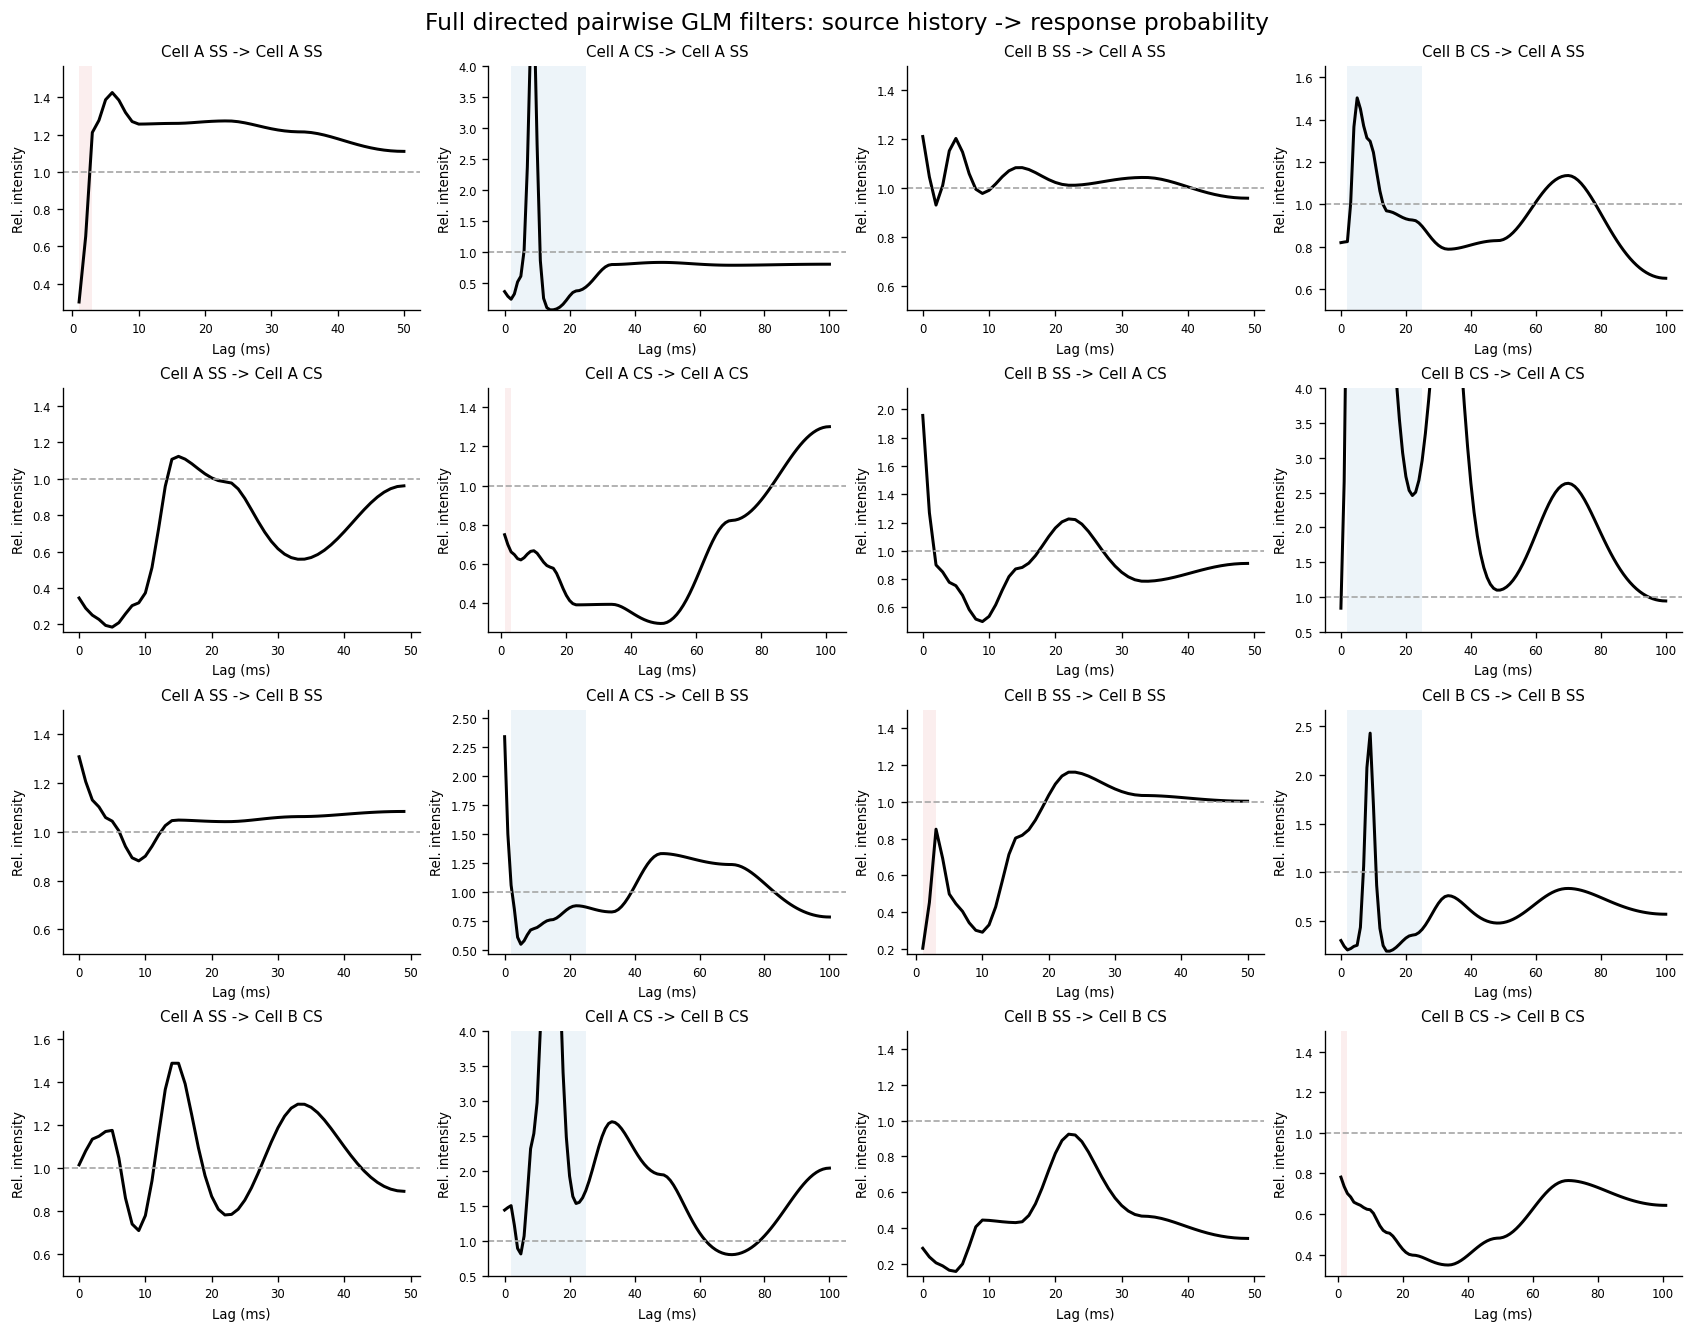

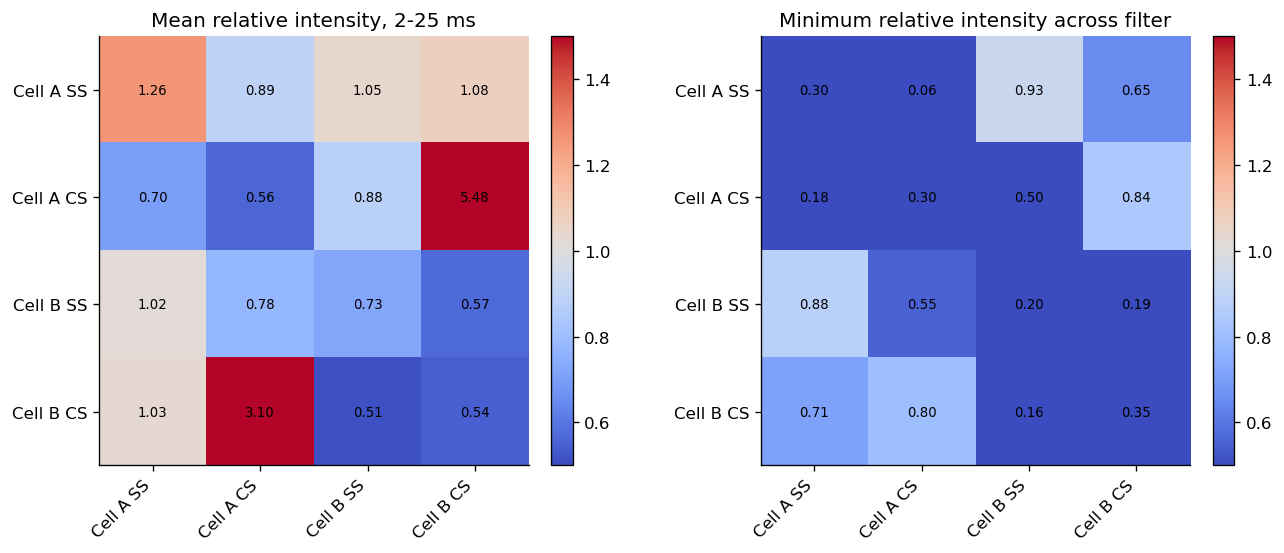

In [11]:
fig, axes = plt.subplots(len(EVENT_KEYS), len(EVENT_KEYS), figsize=(14, 11), sharey=False, constrained_layout=True)
for row_idx, response_key in enumerate(EVENT_KEYS):
    for col_idx, source_key in enumerate(EVENT_KEYS):
        ax = axes[row_idx, col_idx]
        f = filters_by_pair[(source_key, response_key)]
        lags_ms = f['lags_ms']
        rel = f['relative_intensity']
        ax.plot(lags_ms, rel, color='black', lw=1.8)
        ax.axhline(1.0, color='0.65', ls='--', lw=1)
        if source_key == response_key:
            ax.axvspan(1, 3, color='#d62728', alpha=0.08, lw=0)
        elif source_key.startswith('CS'):
            ax.axvspan(2, 25, color='#1f77b4', alpha=0.08, lw=0)
        ax.set_title(f'{EVENT_LABELS[source_key]} -> {EVENT_LABELS[response_key]}', fontsize=9)
        ax.set_xlabel('Lag (ms)', fontsize=8)
        ax.set_ylabel('Rel. intensity', fontsize=8)
        ax.tick_params(axis='both', labelsize=7)
        lo = max(0.0, min(0.5, float(np.nanmin(rel)) * 0.85))
        hi = max(1.5, min(4.0, float(np.nanmax(rel)) * 1.10))
        ax.set_ylim(lo, hi)

fig.suptitle('Full directed pairwise GLM filters: source history -> response probability', fontsize=14)
plt.show()

# Heatmaps summarize each source->response curve with simple early-window statistics.
heat_mean = pairwise_summary.pivot(index='response', columns='source', values='mean_2_25ms').loc[
    [EVENT_LABELS[k] for k in EVENT_KEYS], [EVENT_LABELS[k] for k in EVENT_KEYS]
]
heat_min = pairwise_summary.pivot(index='response', columns='source', values='min_relative_intensity').loc[
    [EVENT_LABELS[k] for k in EVENT_KEYS], [EVENT_LABELS[k] for k in EVENT_KEYS]
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, mat, title in [
    (axes[0], heat_mean, 'Mean relative intensity, 2-25 ms'),
    (axes[1], heat_min, 'Minimum relative intensity across filter'),
]:
    im = ax.imshow(mat.values, cmap='coolwarm', vmin=0.5, vmax=1.5)
    ax.set_xticks(np.arange(len(mat.columns)), labels=mat.columns, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(mat.index)), labels=mat.index)
    ax.set_title(title)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f'{mat.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## 11. Timing-Centric Modulation Report

The 2-25 ms number is only a compact first-pass summary. This section extracts richer timing descriptors from each fitted filter so that the report distinguishes immediate synchrony, delayed inhibition/excitation, and longer recovery.

Timing metrics reported here:

- **Peak inhibition latency**: lag where relative intensity is smallest.
- **Peak excitation latency**: lag where relative intensity is largest.
- **0-5, 5-25, 25-50, 50-100 ms means**: separates immediate synchrony from delayed and late modulation.
- **Duration below 0.9 / above 1.1**: approximate number of ms where the fitted response is at least 10% suppressed or excited.
- **First suppression/excitation latency**: first lag crossing those 10% thresholds.
- **Preferred summary window**: pair-type-specific window chosen from the spike types rather than forcing every pair into 2-25 ms.

These timing metrics are descriptive. They should be paired with bootstrap or jitter controls before treating exact latencies as statistically secure.

In [12]:
def preferred_timing_window(source_key, response_key):
    """Return an interpretation window based on source/response spike classes."""
    source_type = source_key.split('_')[0]
    response_type = response_key.split('_')[0]
    if source_key == response_key and source_type == 'SS':
        return 1.0, 10.0, 'SS self-history refractory/recovery'
    if source_key == response_key and source_type == 'CS':
        return 1.0, 100.0, 'CS self-history / inter-CS refractoriness'
    if source_type == 'CS' and response_type == 'SS':
        return 2.0, 50.0, 'CS-triggered SS pause/modulation'
    if source_type == 'CS' and response_type == 'CS':
        return 0.0, 25.0, 'CS synchrony / common climbing-fiber drive'
    if source_type == 'SS' and response_type == 'SS':
        return 0.0, 10.0, 'SS synchrony plus fast delayed coupling'
    if source_type == 'SS' and response_type == 'CS':
        return 0.0, 50.0, 'SS history before sparse CS events'
    return 0.0, 50.0, 'exploratory window'


def _window_mean(lags_ms, rel, lo, hi):
    mask = (lags_ms >= lo) & (lags_ms <= hi)
    return float(np.nanmean(rel[mask])) if np.any(mask) else np.nan


def _first_latency(lags_ms, mask):
    idx = np.flatnonzero(mask)
    return float(lags_ms[idx[0]]) if idx.size else np.nan


def summarize_filter_timing(source_key, response_key, filt, suppression_threshold=0.9, excitation_threshold=1.1):
    """Convert one fitted filter into timing descriptors for reporting."""
    lags_ms = np.asarray(filt['lags_ms'], dtype=float)
    rel = np.asarray(filt['relative_intensity'], dtype=float)
    pref_lo, pref_hi, pref_reason = preferred_timing_window(source_key, response_key)
    pref_mask = (lags_ms >= pref_lo) & (lags_ms <= pref_hi)

    below = rel < suppression_threshold
    above = rel > excitation_threshold

    return {
        'source': EVENT_LABELS[source_key],
        'response': EVENT_LABELS[response_key],
        'source_key': source_key,
        'response_key': response_key,
        'pair_type': f'{source_key.split("_")[0]} -> {response_key.split("_")[0]}',
        'preferred_window_ms': f'{pref_lo:g}-{pref_hi:g}',
        'preferred_window_reason': pref_reason,
        'preferred_window_mean': _window_mean(lags_ms, rel, pref_lo, pref_hi),
        'peak_inhibition_intensity': float(np.nanmin(rel)),
        'peak_inhibition_latency_ms': float(lags_ms[np.nanargmin(rel)]),
        'peak_excitation_intensity': float(np.nanmax(rel)),
        'peak_excitation_latency_ms': float(lags_ms[np.nanargmax(rel)]),
        'mean_0_5ms': _window_mean(lags_ms, rel, 0, 5),
        'mean_5_25ms': _window_mean(lags_ms, rel, 5, 25),
        'mean_25_50ms': _window_mean(lags_ms, rel, 25, 50),
        'mean_50_100ms': _window_mean(lags_ms, rel, 50, 100),
        'duration_below_0p9_ms': float(np.sum(below) * DT_MS),
        'duration_above_1p1_ms': float(np.sum(above) * DT_MS),
        'first_below_0p9_latency_ms': _first_latency(lags_ms, below),
        'first_above_1p1_latency_ms': _first_latency(lags_ms, above),
        'preferred_window_min': float(np.nanmin(rel[pref_mask])) if np.any(pref_mask) else np.nan,
        'preferred_window_max': float(np.nanmax(rel[pref_mask])) if np.any(pref_mask) else np.nan,
    }


timing_summary = pd.DataFrame([
    summarize_filter_timing(source_key, response_key, filters_by_pair[(source_key, response_key)])
    for response_key in EVENT_KEYS
    for source_key in EVENT_KEYS
])

# Add a compact verbal label for each pair so the table can be read quickly.
def classify_timing_row(row):
    pref_mean = row['preferred_window_mean']
    min_val = row['peak_inhibition_intensity']
    max_val = row['peak_excitation_intensity']
    min_lat = row['peak_inhibition_latency_ms']
    max_lat = row['peak_excitation_latency_ms']
    if pref_mean < 0.8:
        direction = 'net suppression'
    elif pref_mean > 1.2:
        direction = 'net excitation/synchrony'
    else:
        direction = 'weak or mixed modulation'

    if max_lat <= 1 and max_val > 1.1:
        timing = 'strongest excitation is immediate (0-1 ms)'
    elif min_lat <= 3 and min_val < 0.9:
        timing = 'strongest inhibition is very early'
    elif 3 < min_lat <= 25 and min_val < 0.9:
        timing = 'delayed inhibition peak'
    elif 3 < max_lat <= 25 and max_val > 1.1:
        timing = 'delayed excitation peak'
    else:
        timing = 'broad or late peak'
    return f'{direction}; {timing}'


timing_summary['timing_interpretation'] = timing_summary.apply(classify_timing_row, axis=1)

cols = [
    'source', 'response', 'preferred_window_ms', 'preferred_window_reason',
    'preferred_window_mean', 'peak_inhibition_intensity', 'peak_inhibition_latency_ms',
    'peak_excitation_intensity', 'peak_excitation_latency_ms',
    'mean_0_5ms', 'mean_5_25ms', 'mean_25_50ms', 'mean_50_100ms',
    'duration_below_0p9_ms', 'duration_above_1p1_ms',
    'first_below_0p9_latency_ms', 'first_above_1p1_latency_ms',
    'timing_interpretation',
]

print('Timing-focused source -> response report:')
display(timing_summary[cols])

# A compact table for the most commonly discussed relationships.
focus_pairs = [
    ('SS_A', 'SS_A'), ('CS_A', 'SS_A'), ('SS_A', 'SS_B'), ('CS_A', 'SS_B'),
    ('CS_A', 'CS_B'), ('CS_B', 'CS_A'), ('CS_B', 'SS_B'), ('SS_B', 'SS_B'),
]
focus_timing_summary = pd.concat([
    timing_summary[(timing_summary['source_key'] == s) & (timing_summary['response_key'] == r)]
    for s, r in focus_pairs
], ignore_index=True)
print('Focused timing summary for key biological comparisons:')
display(focus_timing_summary[[
    'source', 'response', 'preferred_window_ms', 'preferred_window_mean',
    'peak_inhibition_intensity', 'peak_inhibition_latency_ms',
    'peak_excitation_intensity', 'peak_excitation_latency_ms',
    'duration_below_0p9_ms', 'duration_above_1p1_ms', 'timing_interpretation'
]])

Timing-focused source -> response report:


,source,response,preferred_window_ms,preferred_window_reason,preferred_window_mean,peak_inhibition_intensity,peak_inhibition_latency_ms,peak_excitation_intensity,peak_excitation_latency_ms,mean_0_5ms,mean_5_25ms,mean_25_50ms,mean_50_100ms,duration_below_0p9_ms,duration_above_1p1_ms,first_below_0p9_latency_ms,first_above_1p1_latency_ms,timing_interpretation
0,Cell A SS,Cell A SS,1-10,SS self-history refractory/recovery,1.148868,0.301333,1.0,1.425913,6.0,0.966300,1.286754,1.188045,1.110108,2.0,48.0,1.0,3.0,weak or mixed modulation; strongest inhibition...
1,Cell A CS,Cell A SS,2-50,CS-triggered SS pause/modulation,0.827581,0.061411,14.0,5.107033,9.0,0.384219,0.969134,0.752498,0.795258,96.0,4.0,0.0,7.0,weak or mixed modulation; delayed inhibition peak
2,Cell B SS,Cell A SS,0-10,SS synchrony plus fast delayed coupling,1.066301,0.931004,2.0,1.211430,0.0,1.092668,1.047646,1.009805,NaN,0.0,4.0,NaN,0.0,weak or mixed modulation; strongest excitation...
3,Cell B CS,Cell A SS,2-50,CS-triggered SS pause/modulation,0.943939,0.651601,100.0,1.502385,5.0,1.056629,1.078607,0.819371,0.912602,51.0,17.0,0.0,4.0,weak or mixed modulation; delayed excitation peak
4,Cell A SS,Cell A CS,0-50,SS history before sparse CS events,0.699759,0.184874,5.0,1.123021,15.0,0.248466,0.768372,0.737533,NaN,34.0,3.0,0.0,14.0,net suppression; delayed inhibition peak
5,Cell A CS,Cell A CS,1-100,CS self-history / inter-CS refractoriness,0.659131,0.295950,49.0,1.301232,101.0,0.676854,0.546474,0.357332,0.844652,78.0,14.0,1.0,88.0,net suppression; broad or late peak
6,Cell B SS,Cell A CS,0-50,SS history before sparse CS events,0.904294,0.499712,9.0,1.957836,0.0,1.084875,0.887689,0.878177,NaN,30.0,9.0,3.0,0.0,weak or mixed modulation; strongest excitation...
7,Cell B CS,Cell A CS,0-25,CS synchrony / common climbing-fiber drive,5.197482,0.843354,0.0,10.894314,9.0,4.491289,5.406561,3.365057,1.719602,1.0,91.0,0.0,1.0,net excitation/synchrony; strongest inhibition...
8,Cell A SS,Cell B SS,0-10,SS synchrony plus fast delayed coupling,1.041901,0.880644,9.0,1.306687,0.0,1.140644,1.006624,1.066688,NaN,3.0,4.0,8.0,0.0,weak or mixed modulation; strongest excitation...
9,Cell A CS,Cell B SS,2-50,CS-triggered SS pause/modulation,0.907651,0.553246,5.0,2.340778,0.0,1.154730,0.766312,1.027861,1.101670,47.0,41.0,3.0,0.0,weak or mixed modulation; strongest excitation...


Focused timing summary for key biological comparisons:


,source,response,preferred_window_ms,preferred_window_mean,peak_inhibition_intensity,peak_inhibition_latency_ms,peak_excitation_intensity,peak_excitation_latency_ms,duration_below_0p9_ms,duration_above_1p1_ms,timing_interpretation
0,Cell A SS,Cell A SS,1-10,1.148868,0.301333,1.0,1.425913,6.0,2.0,48.0,weak or mixed modulation; strongest inhibition...
1,Cell A CS,Cell A SS,2-50,0.827581,0.061411,14.0,5.107033,9.0,96.0,4.0,weak or mixed modulation; delayed inhibition peak
2,Cell A SS,Cell B SS,0-10,1.041901,0.880644,9.0,1.306687,0.0,3.0,4.0,weak or mixed modulation; strongest excitation...
3,Cell A CS,Cell B SS,2-50,0.907651,0.553246,5.0,2.340778,0.0,47.0,41.0,weak or mixed modulation; strongest excitation...
4,Cell A CS,Cell B CS,0-25,2.973756,0.801093,70.0,7.974890,14.0,13.0,78.0,net excitation/synchrony; delayed excitation peak
5,Cell B CS,Cell A CS,0-25,5.197482,0.843354,0.0,10.894314,9.0,1.0,91.0,net excitation/synchrony; strongest inhibition...
6,Cell B CS,Cell B SS,2-50,0.584332,0.188393,15.0,2.431396,9.0,97.0,3.0,net suppression; delayed inhibition peak
7,Cell B SS,Cell B SS,1-10,0.448889,0.204913,1.0,1.160097,24.0,17.0,7.0,net suppression; strongest inhibition is very ...


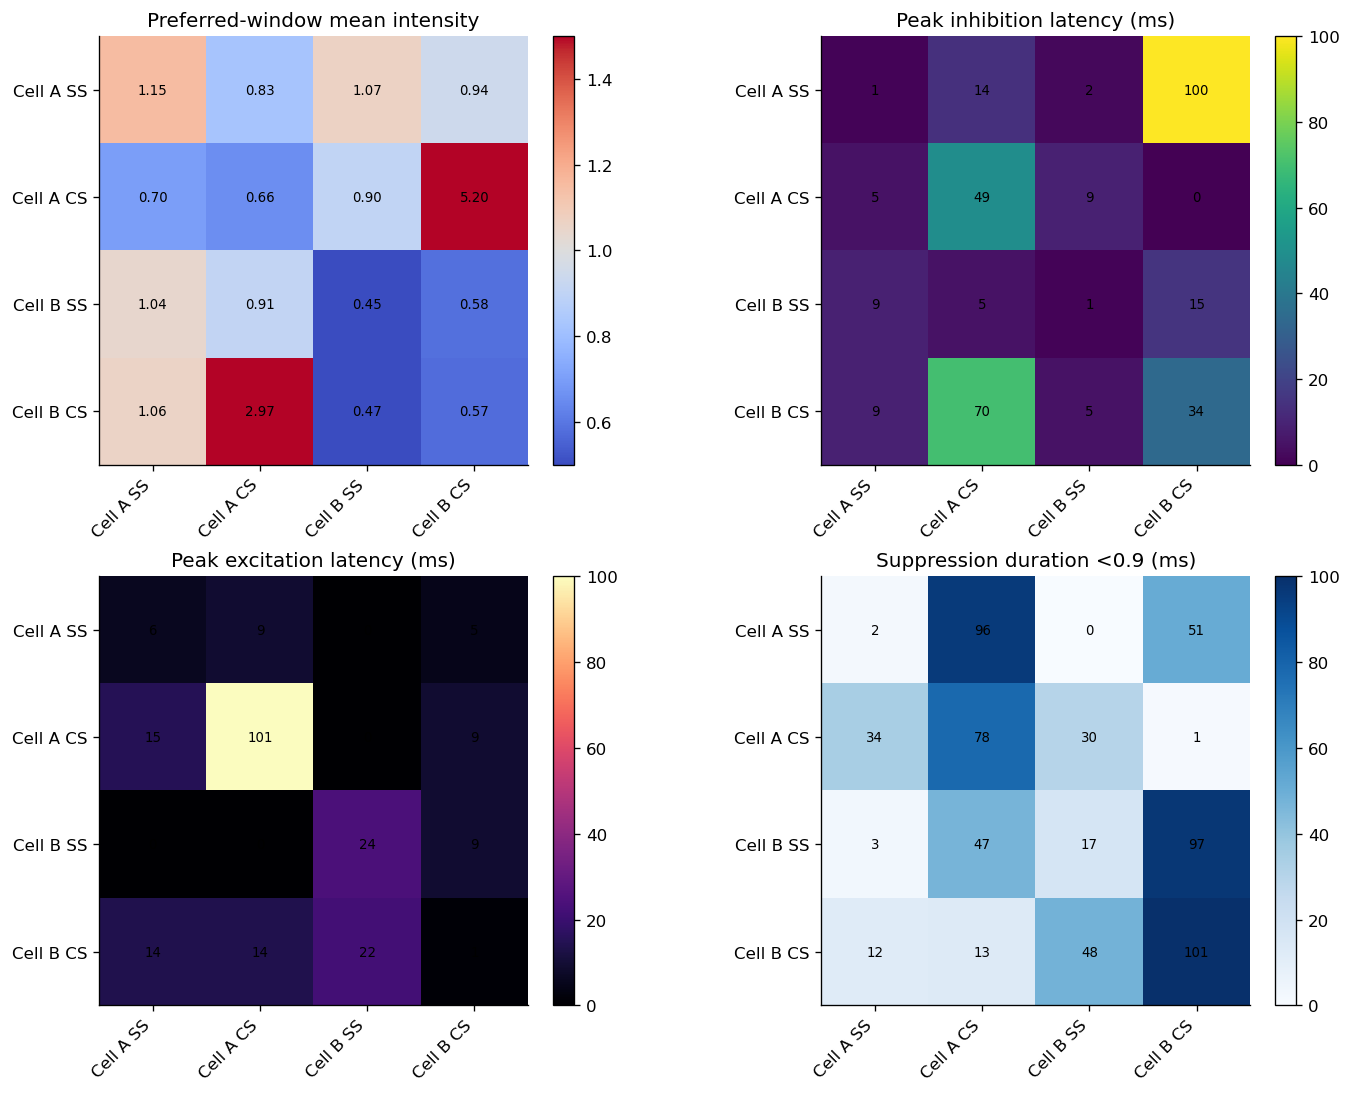

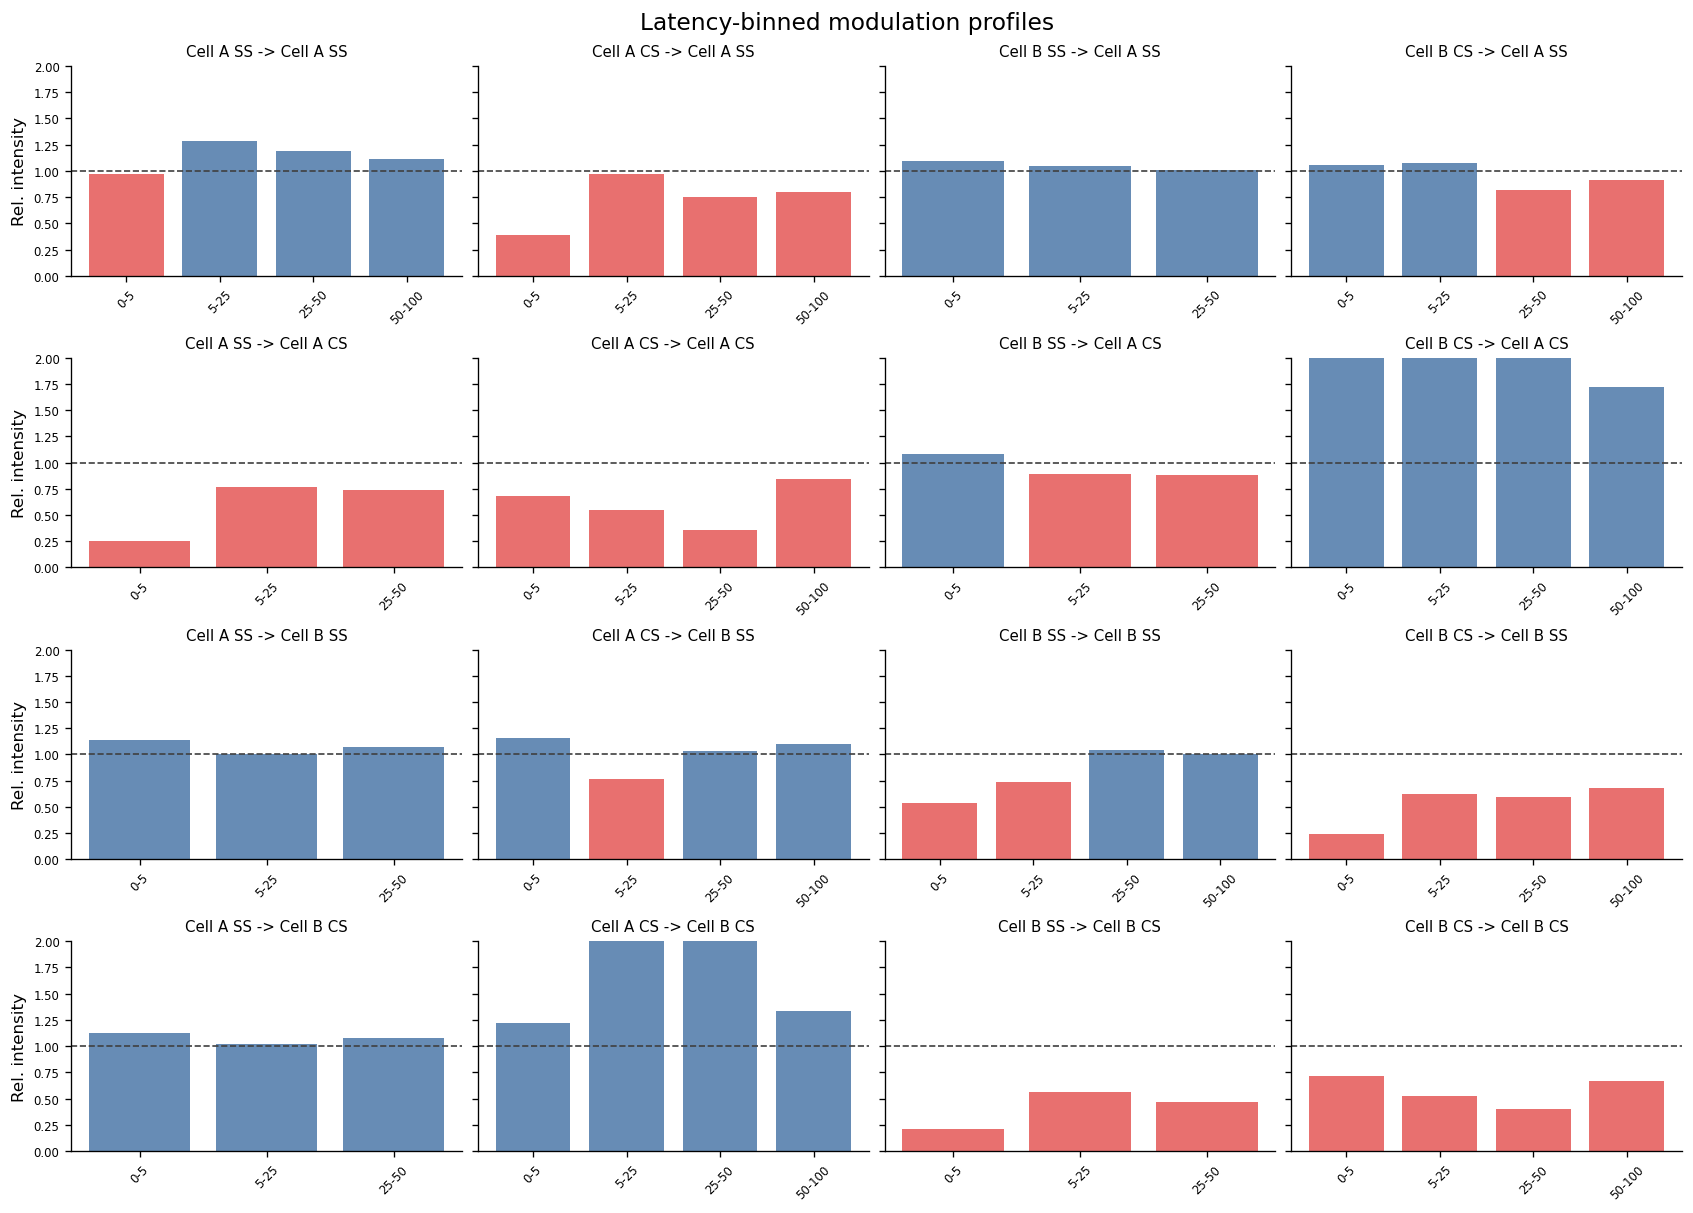

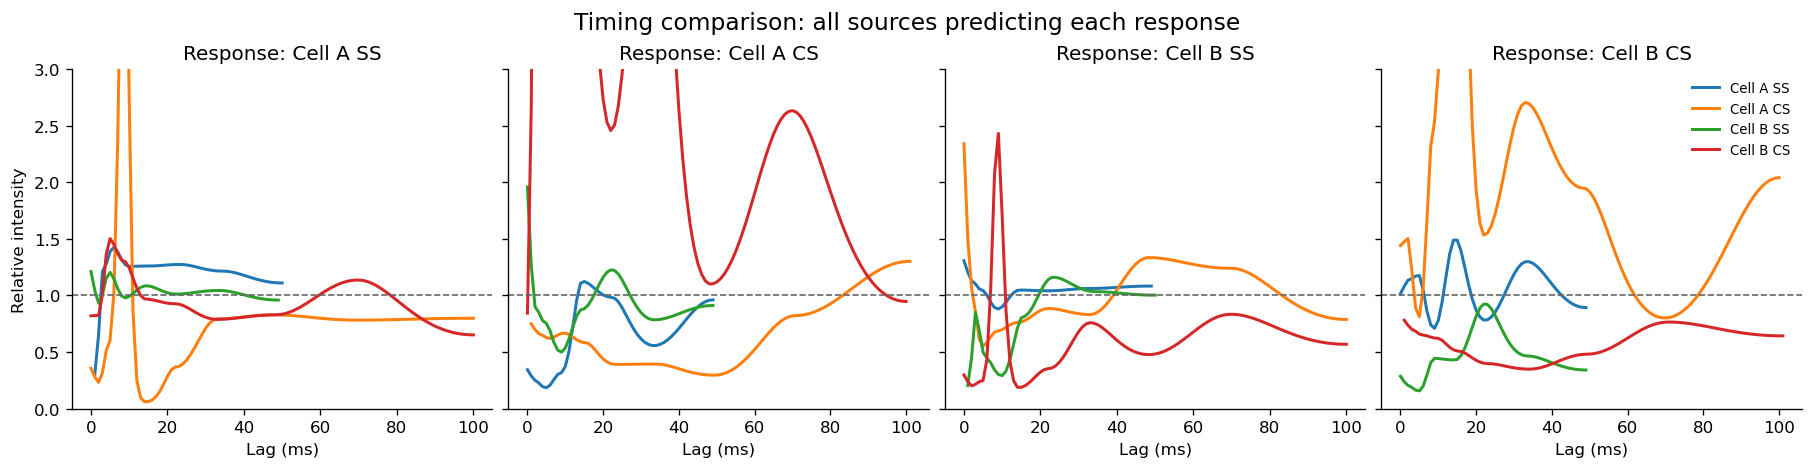

In [13]:
# Timing heatmaps: these are often easier to scan than the full 16 filter curves.
row_order = [EVENT_LABELS[k] for k in EVENT_KEYS]
col_order = [EVENT_LABELS[k] for k in EVENT_KEYS]

heat_specs = [
    ('preferred_window_mean', 'Preferred-window mean intensity', 0.5, 1.5, 'coolwarm'),
    ('peak_inhibition_latency_ms', 'Peak inhibition latency (ms)', 0, 100, 'viridis'),
    ('peak_excitation_latency_ms', 'Peak excitation latency (ms)', 0, 100, 'magma'),
    ('duration_below_0p9_ms', 'Suppression duration <0.9 (ms)', 0, 100, 'Blues'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for ax, (value_col, title, vmin, vmax, cmap) in zip(axes.ravel(), heat_specs):
    mat = timing_summary.pivot(index='response', columns='source', values=value_col).loc[row_order, col_order]
    im = ax.imshow(mat.values, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(col_order)), labels=col_order, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(row_order)), labels=row_order)
    ax.set_title(title)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]
            label = f'{val:.2f}' if 'intensity' in title.lower() else f'{val:.0f}'
            ax.text(j, i, label, ha='center', va='center', fontsize=8, color='black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

# Latency-binned profile plot: immediate, early delayed, mid, and late windows for each pair.
profile_cols = ['mean_0_5ms', 'mean_5_25ms', 'mean_25_50ms', 'mean_50_100ms']
profile_labels = ['0-5', '5-25', '25-50', '50-100']
fig, axes = plt.subplots(len(EVENT_KEYS), len(EVENT_KEYS), figsize=(14, 10), sharey=True, constrained_layout=True)
for row_idx, response_key in enumerate(EVENT_KEYS):
    for col_idx, source_key in enumerate(EVENT_KEYS):
        ax = axes[row_idx, col_idx]
        row = timing_summary[(timing_summary['source_key'] == source_key) & (timing_summary['response_key'] == response_key)].iloc[0]
        vals = [row[c] for c in profile_cols]
        colors = ['#4c78a8' if v >= 1 else '#e45756' for v in vals]
        ax.bar(profile_labels, vals, color=colors, alpha=0.85)
        ax.axhline(1.0, color='0.25', lw=1, ls='--')
        ax.set_ylim(0, max(2.0, min(5.0, np.nanmax(vals) * 1.2)))
        ax.set_title(f'{EVENT_LABELS[source_key]} -> {EVENT_LABELS[response_key]}', fontsize=9)
        ax.tick_params(axis='x', labelrotation=45, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        if col_idx == 0:
            ax.set_ylabel('Rel. intensity')
fig.suptitle('Latency-binned modulation profiles', fontsize=14)
plt.show()

# Overlay source->response filters by response class to compare timing across sources.
fig, axes = plt.subplots(1, len(EVENT_KEYS), figsize=(15, 3.8), sharey=True, constrained_layout=True)
for ax, response_key in zip(axes, EVENT_KEYS):
    for source_key in EVENT_KEYS:
        f = filters_by_pair[(source_key, response_key)]
        ax.plot(f['lags_ms'], f['relative_intensity'], lw=1.8, label=EVENT_LABELS[source_key])
    ax.axhline(1.0, color='0.4', ls='--', lw=1)
    ax.set_title(f'Response: {EVENT_LABELS[response_key]}')
    ax.set_xlabel('Lag (ms)')
    ax.set_ylim(0, 3)
axes[0].set_ylabel('Relative intensity')
axes[-1].legend(frameon=False, fontsize=8, loc='upper right')
fig.suptitle('Timing comparison: all sources predicting each response', fontsize=14)
plt.show()

## Notes for Real Recordings

For real two-cell recordings, set `USE_SYNTHETIC_DATA = False` in the setup cell and choose `REAL_SESSION_INDEX`. The loader assumes channel 0 is Cell A and channel 1 is Cell B, matching the two-cell Spike Detector outputs in `20260611_A64_2PCs_MC`. For publication analyses, fit both directions (`A -> B` and `B -> A`) and repeat the model for multiple sessions rather than relying on a single selected recording.